# Primera eyección de masa coronal fuera del Sol

**En promedio una vez cada ~3 años por estrella M (con varianza enorme).** Esa es la frecuencia con la que ocurren explosiones de radio como la que el LOFAR captó por primera vez fuera del Sol — la firma de una eyección de masa coronal en una M dwarf a 32 años luz.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-primera-eyeccion-estelar-fuera-sol/notebook.ipynb)

**Paper**: Callingham et al. (2025), *Nature* — [DOI: 10.1038/s41586-025-09715-3](https://doi.org/10.1038/s41586-025-09715-3)
**Datos y código**: [Repositorio del autor (Rob Kavanagh)](https://github.com/robkavanagh/papers/tree/main/type-II)


## ¿Por qué importa esto?

Las eyecciones de masa coronal (*coronal mass ejections*, CMEs) son los plasmazos magnetizados más violentos que una estrella puede lanzar. En el Sol las conocemos bien — afectan satélites, redes eléctricas y son el principal actor del clima espacial. En cualquier **otra** estrella, hasta este paper, nadie había visto una directamente. Solo se inferían a partir de fulguraciones (*flares*) intensas, asumiendo que se comportaban igual que las solares.

El equipo apuntó el LOFAR — un radiotelescopio de baja frecuencia en Países Bajos — hacia **StKM 1-1262**, una M dwarf temprana a 32 años luz. Capturaron una explosión de radio que dura ~4 minutos y que tiene la firma exacta de un *type II burst* solar: la deriva característica de una onda de choque viajando por la corona estelar. Eso es la huella dactilar de una CME.

Lo que hacemos aquí es abrir la trastienda: **el dynamic spectrum** (el mapa de qué frecuencia llegó en qué instante — lo que el telescopio realmente detectó) y los **posteriors del modelo MCMC** (el rango de valores compatibles con los datos, después de un muestreo bayesiano) que el equipo usó para descartar una explicación alternativa.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RATE_POR_DIA = 0.84e-3        # Tasa de eventos similares (eventos/día/estrella)
RATE_LO = 0.84e-3 - 0.69e-3   # Límite inferior 1σ
RATE_HI = 0.84e-3 + 1.94e-3   # Límite superior 1σ
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO = '#BBBBBB'
FUENTE = 'Fuente: Callingham et al. (2025), Nature | Datos: github.com/robkavanagh/papers'

# Imports
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Carga de datos
spectrum = pd.read_csv('datos/dynamic_spectrum.csv')
posteriors = pd.read_csv('datos/posteriors_loop_modelo.csv')
resumen = pd.read_csv('datos/parametros_resumen.csv')

print(f"Dynamic spectrum: {len(spectrum):,} filas (tiempo × frecuencia)")
print(f"  Tiempo: {spectrum['time_min'].min():.2f} a {spectrum['time_min'].max():.2f} min")
print(f"  Frecuencia: {spectrum['freq_mhz'].min():.1f} a {spectrum['freq_mhz'].max():.1f} MHz")
print(f"  Bins únicos: {spectrum['time_min'].nunique()} × {spectrum['freq_mhz'].nunique()}")
print()
print(f"Posteriors MCMC: {len(posteriors):,} muestras × {posteriors.shape[1]} parámetros")
print(f"Resumen: {len(resumen)} parámetros del modelo ECMI")


Dynamic spectrum: 14,400 filas (tiempo × frecuencia)
  Tiempo: -1.99 a 1.89 min
  Frecuencia: 120.3 a 167.0 MHz
  Bins únicos: 30 × 480

Posteriors MCMC: 6,356 muestras × 9 parámetros
Resumen: 9 parámetros del modelo ECMI


## Aquí está.

Esto es lo que LOFAR vio durante 4,3 minutos, en la banda de 120-167 MHz.

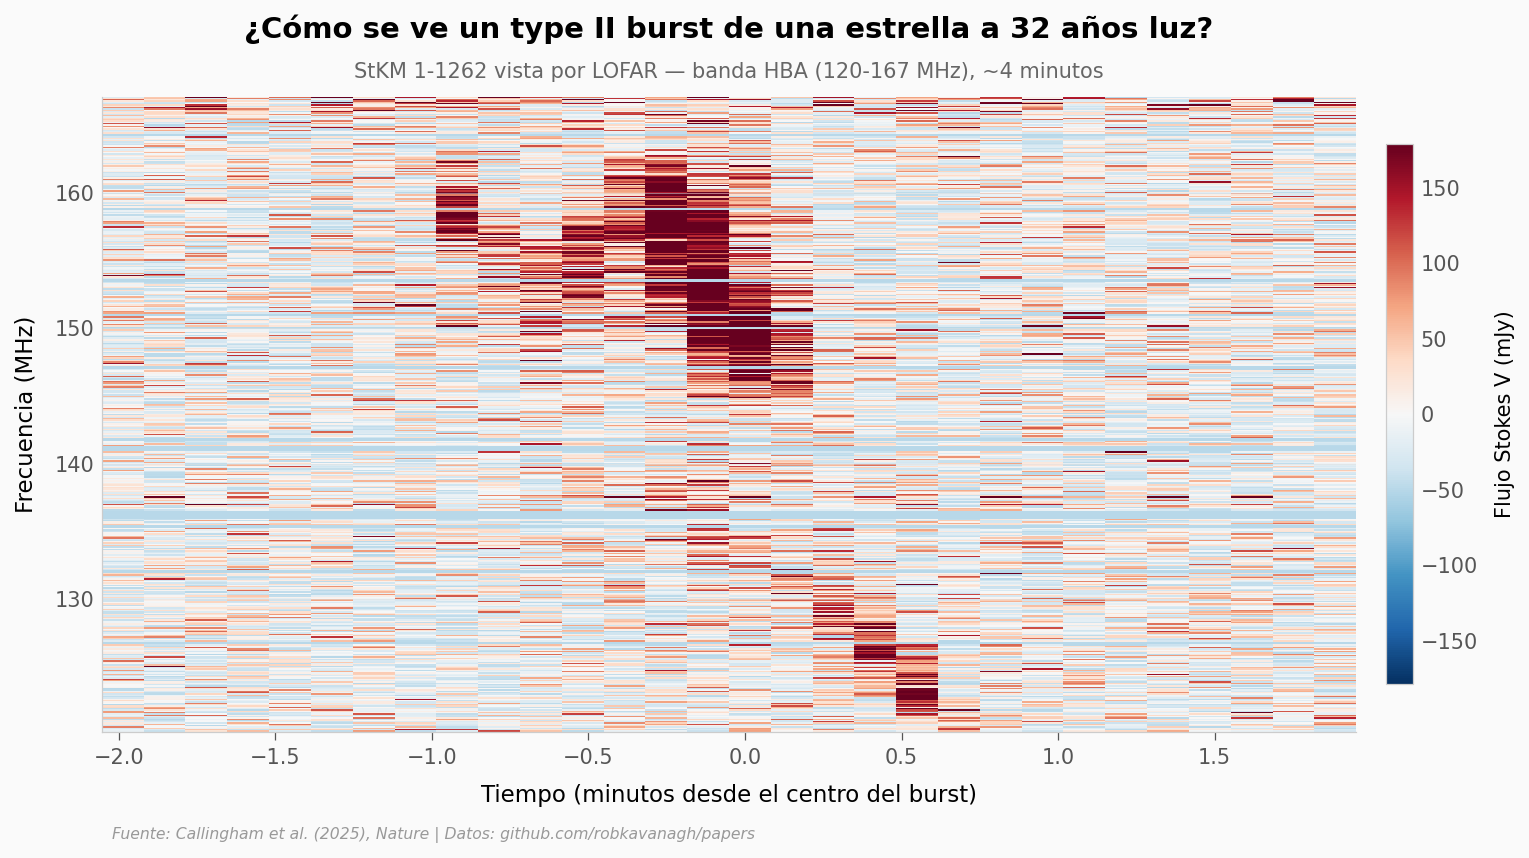

In [2]:
# Pivot a matriz 2D (tiempo × frecuencia)
pivot = spectrum.pivot_table(
    index='freq_mhz', columns='time_min', values='flux_v_mjy', aggfunc='mean'
)
times = pivot.columns.values
freqs = pivot.index.values
flux_2d = pivot.values

fig, ax = plt.subplots(figsize=(13, 5.5))

# Limites simétricos para Stokes V (puede ser positivo o negativo)
vmax = np.nanpercentile(np.abs(flux_2d), 98)
mesh = ax.pcolormesh(
    times, freqs, flux_2d,
    cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto'
)

cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Flujo Stokes V (mJy)', fontsize=10)

ax.set_xlabel('Tiempo (minutos desde el centro del burst)', fontsize=11)
ax.set_ylabel('Frecuencia (MHz)', fontsize=11)
ax.set_title('¿Cómo se ve un type II burst de una estrella a 32 años luz?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'StKM 1-1262 vista por LOFAR — banda HBA (120-167 MHz), ~4 minutos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dynamic_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()


La estructura llama la atención por dos razones. Primero: la emisión está fuertemente polarizada en Stokes V — el rojo y el azul intensos no son ruido, son polarización circular en sentidos opuestos. Las CMEs solares producen exactamente este patrón cuando la onda de choque cruza la corona.

Segundo, y más importante: la deriva. La emisión empieza a frecuencias altas y baja a medida que pasa el tiempo. Eso es lo que delata una onda de choque alejándose de la estrella — al subir la onda atraviesa plasma cada vez más diluido, y el plasma diluido emite a frecuencias más bajas. La deriva es la firma física de algo moviéndose hacia afuera.


## Pero, ¿y si no es una CME?

Hay una explicación alternativa: el burst podría venir de un *loop* magnético cerrado en la corona, sin que nada salga de la estrella. Para descartar (o confirmar) esa hipótesis, el equipo ajustó un modelo de emisión por *cyclotron maser* (ECMI — un mecanismo en el que electrones atrapados en un loop magnético emiten radio sin necesidad de una onda de choque saliendo) con MCMC — 6.356 muestras posteriores explorando 9 parámetros del loop.

Si el modelo del loop ajustara perfectamente, el caso de la CME se debilitaría. Veamos qué dicen los posteriors.


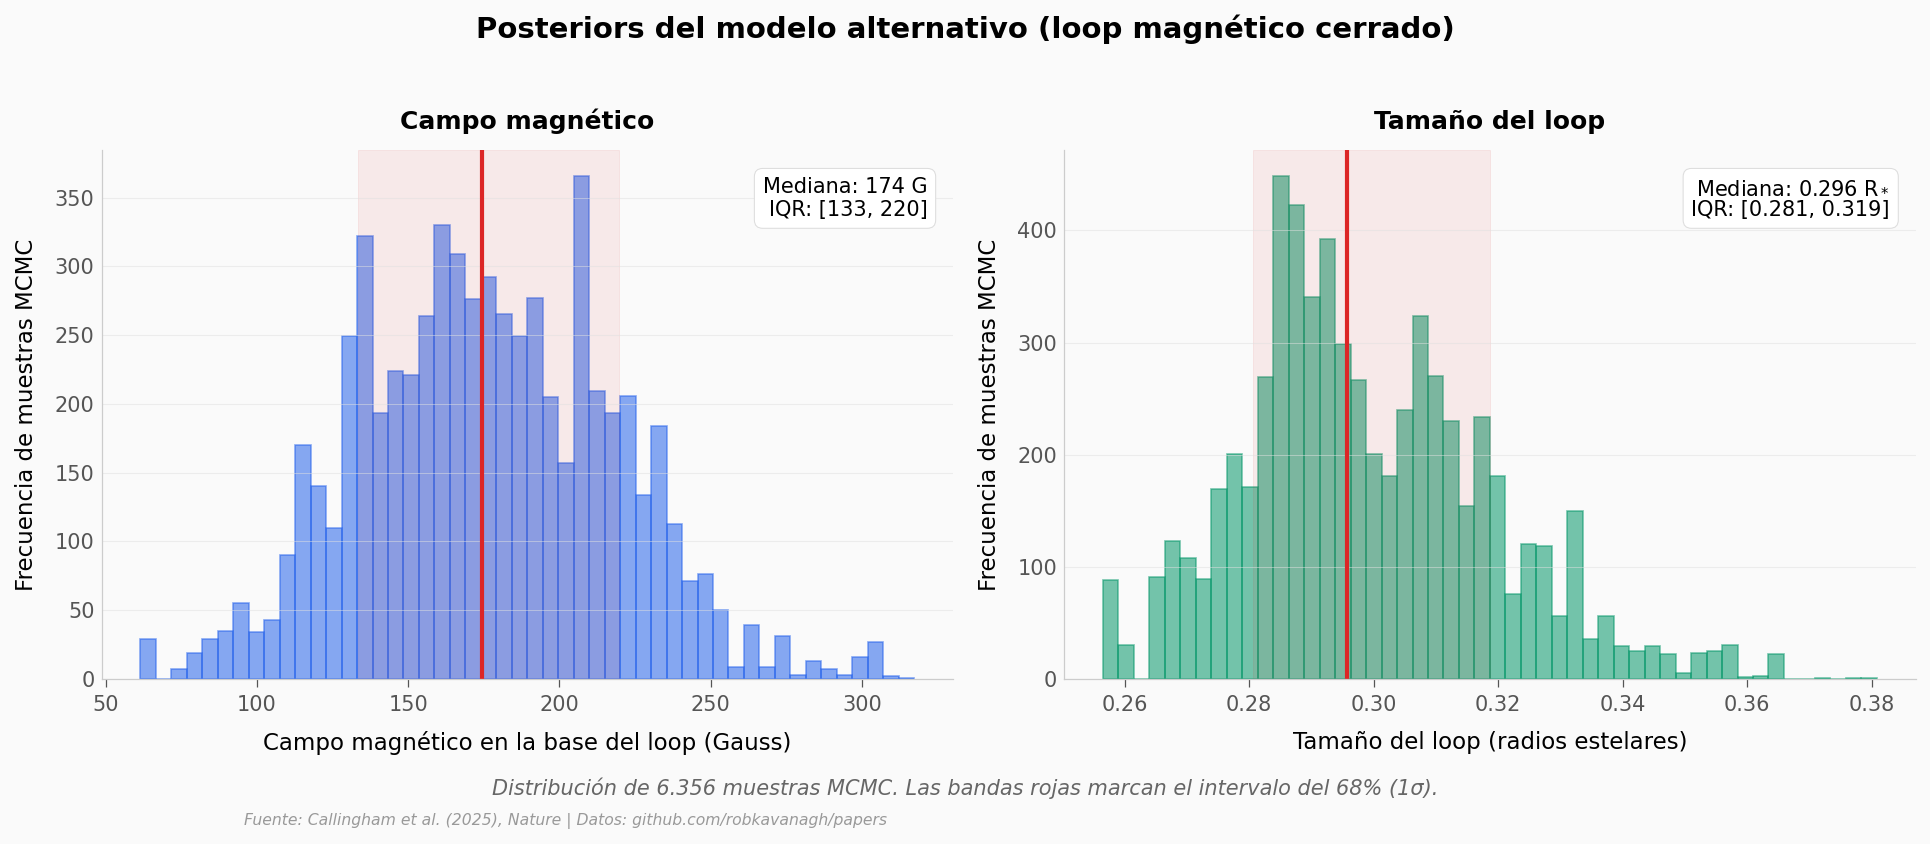

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: campo magnético en la base del loop
ax = axes[0]
ax.hist(posteriors['b_fp_gauss'], bins=50, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.8)
mediana_b = posteriors['b_fp_gauss'].median()
q16_b, q84_b = posteriors['b_fp_gauss'].quantile([0.16, 0.84])
ax.axvline(mediana_b, color=COLOR_ALERTA, linewidth=2, linestyle='-')
ax.axvspan(q16_b, q84_b, color=COLOR_ALERTA, alpha=0.08)
ax.set_xlabel('Campo magnético en la base del loop (Gauss)', fontsize=11)
ax.set_ylabel('Frecuencia de muestras MCMC', fontsize=11)
ax.set_title('Campo magnético', fontsize=12, fontweight='bold', pad=10)
ax.text(0.97, 0.95, f'Mediana: {mediana_b:.0f} G\nIQR: [{q16_b:.0f}, {q84_b:.0f}]',
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#DDDDDD'))

# Panel B: tamaño del loop (en radios estelares)
ax = axes[1]
ax.hist(posteriors['l_rstar'], bins=50, color=COLOR_SECUNDARIO, alpha=0.55,
        edgecolor=COLOR_SECUNDARIO, linewidth=0.8)
mediana_l = posteriors['l_rstar'].median()
q16_l, q84_l = posteriors['l_rstar'].quantile([0.16, 0.84])
ax.axvline(mediana_l, color=COLOR_ALERTA, linewidth=2, linestyle='-')
ax.axvspan(q16_l, q84_l, color=COLOR_ALERTA, alpha=0.08)
ax.set_xlabel('Tamaño del loop (radios estelares)', fontsize=11)
ax.set_ylabel('Frecuencia de muestras MCMC', fontsize=11)
ax.set_title('Tamaño del loop', fontsize=12, fontweight='bold', pad=10)
ax.text(0.97, 0.95, f'Mediana: {mediana_l:.3f} R$_*$\nIQR: [{q16_l:.3f}, {q84_l:.3f}]',
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#DDDDDD'))

fig.suptitle('Posteriors del modelo alternativo (loop magnético cerrado)',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, -0.02, 'Distribución de 6.356 muestras MCMC. Las bandas rojas marcan el intervalo del 68% (1σ).',
         ha='center', fontsize=10, color='#666666', style='italic')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/posteriors_loop.png', dpi=200, bbox_inches='tight')
plt.show()


El modelo alternativo no es absurdo: ajusta razonablemente bien con un campo de ~174 G y un loop de ~0,3 radios estelares (≈146.000 km, comparable al diámetro de Júpiter). Pero el paper apunta a un detalle que rompe la explicación: el **grosor del cono de emisión** que el modelo necesita para reproducir el flujo observado.


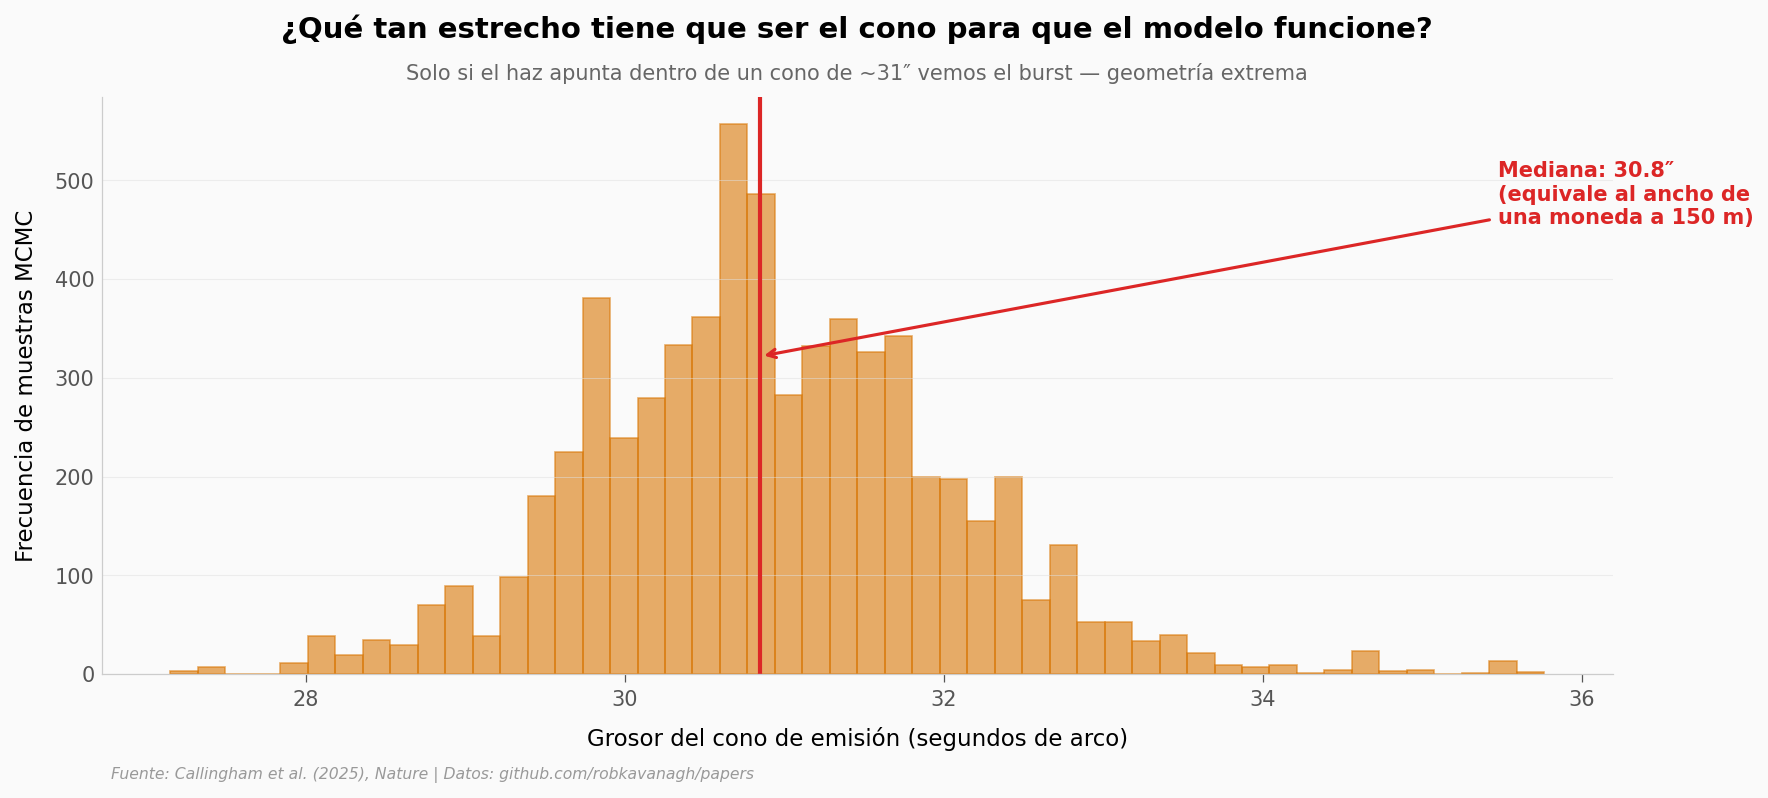

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

dalpha = posteriors['dalpha_deg']
dalpha_arcsec = dalpha * 3600  # grados → segundos de arco

ax.hist(dalpha_arcsec, bins=50, color=COLOR_REFERENCIA, alpha=0.6,
        edgecolor=COLOR_REFERENCIA, linewidth=0.8)
mediana_arcsec = dalpha_arcsec.median()
ax.axvline(mediana_arcsec, color=COLOR_ALERTA, linewidth=2)

ax.set_xlabel('Grosor del cono de emisión (segundos de arco)', fontsize=11)
ax.set_ylabel('Frecuencia de muestras MCMC', fontsize=11)
ax.set_title('¿Qué tan estrecho tiene que ser el cono para que el modelo funcione?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Solo si el haz apunta dentro de un cono de ~31″ vemos el burst — geometría extrema',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.annotate(
    f'Mediana: {mediana_arcsec:.1f}″\n(equivale al ancho de\nuna moneda a 150 m)',
    xy=(mediana_arcsec, ax.get_ylim()[1] * 0.55),
    xytext=(mediana_arcsec * 1.15, ax.get_ylim()[1] * 0.78),
    fontsize=10, color=COLOR_ALERTA, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5)
)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cono_emision.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué tan raro es ver una de estas?

Si el cono tiene que ser tan estrecho para que la geometría coincida — y aun así, en ~10.500 horas de monitoreo LOFAR sobre M dwarfs cercanas, el equipo solo encontró una detección clara — ¿con qué frecuencia ocurre algo así por estrella?


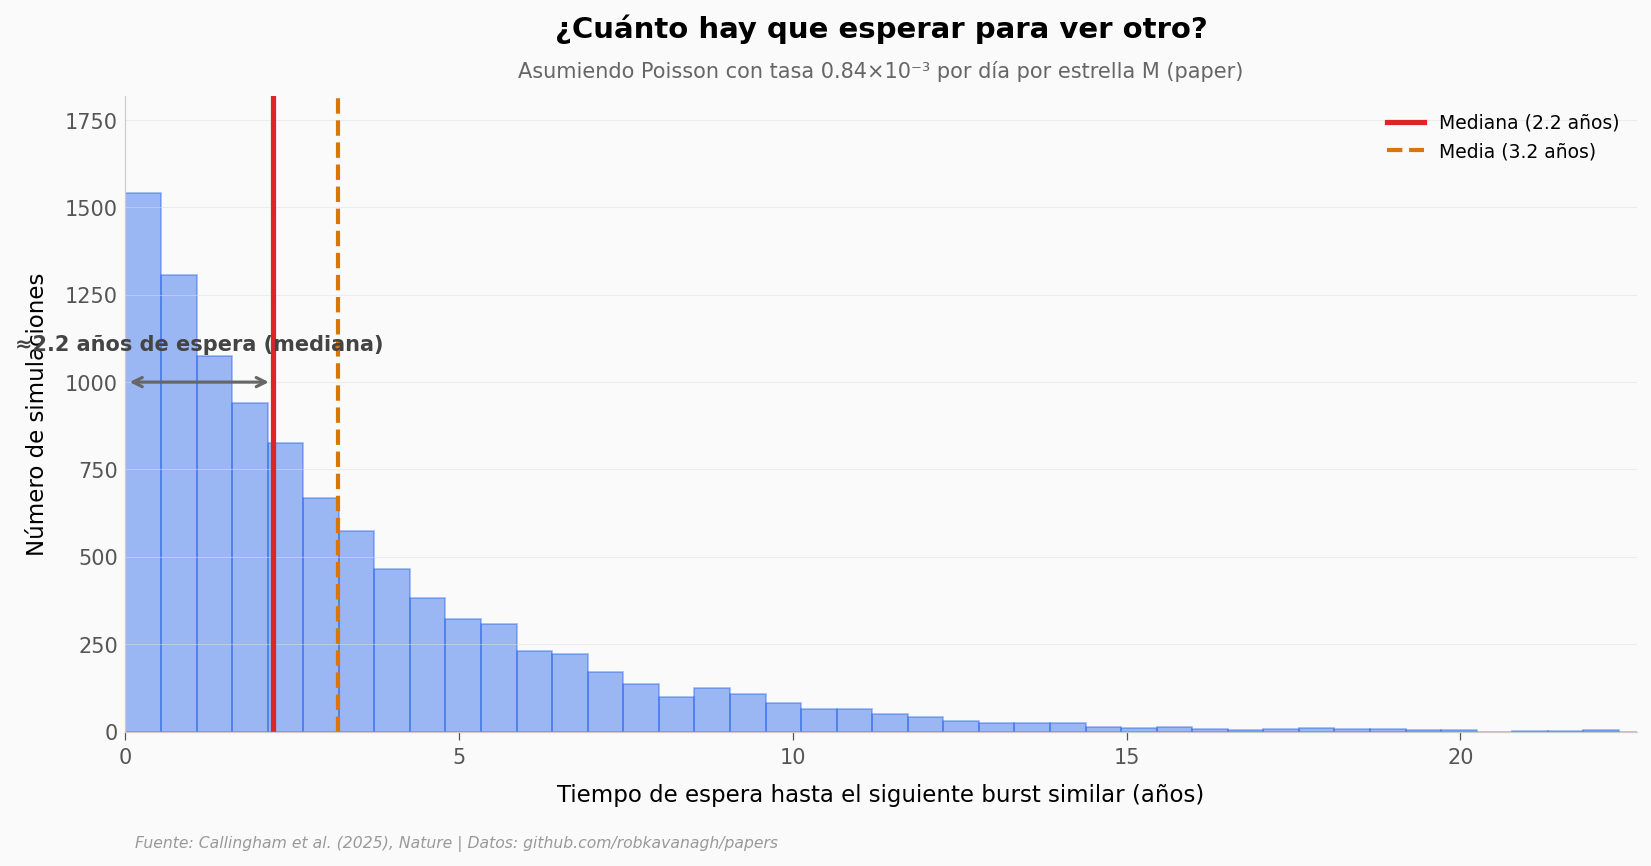

Mediana de espera: 2.21 años
Media de espera (1/R): 3.19 años
Probabilidad de ver ≥1 evento en 1 año: 26.4%


In [5]:
# Modelo Poisson: si la rate es R eventos/día, el tiempo entre eventos
# se distribuye exponencialmente con media 1/R.
np.random.seed(42)
n_sim = 10_000
intervalos_dias = np.random.exponential(scale=1/RATE_POR_DIA, size=n_sim)
intervalos_anios = intervalos_dias / 365.25

fig, ax = plt.subplots(figsize=(13, 5.5))
n, bins, patches = ax.hist(
    intervalos_anios, bins=50, color=COLOR_DATOS, alpha=0.45,
    edgecolor=COLOR_DATOS, linewidth=0.8
)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

mediana_anios = np.median(intervalos_anios)
media_anios = np.mean(intervalos_anios)

ax.axvline(mediana_anios, color=COLOR_ALERTA, linewidth=2.5, label=f'Mediana ({mediana_anios:.1f} años)')
ax.axvline(media_anios, color=COLOR_REFERENCIA, linewidth=2, linestyle='--',
           label=f'Media ({media_anios:.1f} años)')

ax.annotate('', xy=(mediana_anios, y_max * 0.55), xytext=(0, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mediana_anios / 2, y_max * 0.6,
        f'≈{mediana_anios:.1f} años de espera (mediana)',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('Tiempo de espera hasta el siguiente burst similar (años)', fontsize=11)
ax.set_ylabel('Número de simulaciones', fontsize=11)
ax.set_title('¿Cuánto hay que esperar para ver otro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Asumiendo Poisson con tasa {RATE_POR_DIA*1000:.2f}×10⁻³ por día por estrella M (paper)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim(0, intervalos_anios.max() * 0.85)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/intervalo_eventos.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mediana de espera: {mediana_anios:.2f} años")
print(f"Media de espera (1/R): {media_anios:.2f} años")
print(f"Probabilidad de ver ≥1 evento en 1 año: {(1 - np.exp(-RATE_POR_DIA * 365.25)) * 100:.1f}%")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El burst tiene firma de *type II* solar (deriva en frecuencia, polarización Stokes V) | ✅ | El dynamic spectrum lo muestra directamente. Las propiedades coinciden con emisión de plasma fundamental (paper, Fig. 2) |
| El modelo alternativo (loop ECMI cerrado) ajusta los datos | ⚠️ | Recupera la deriva general pero no la sub-estructura completa del burst (Extended Data Fig. 1 del paper). Posteriors aquí son del modelo alternativo, no del fit plasma emission |
| Tasa de eventos similares: 0,84 × 10⁻³ por día por estrella M | ✅ | Reportada explícitamente en el abstract con rango -0,69 / +1,94 × 10⁻³ |
| Las CMEs estelares afectan la atmósfera de exoplanetas | ⚠️ | El paper lo enmarca como implicación (*implies*), no como demostración. Una sola detección no establece estadística poblacional |

> **Limitaciones:** los posteriors de este notebook son del fit ECMI alternativo — sirven para mostrar dónde el modelo "necesita ajustar" para acercarse a los datos, no para confirmar que el burst sea del loop. La interpretación de CME viene del análisis comparativo del paper, que también usa la posición espacial del burst (off-source en el dirty map). El intervalo de 3,3 años es la **media** (1/R) asumiendo un proceso Poisson; la **mediana** es más corta (~2,2 años) porque la distribución exponencial está sesgada a la derecha. La varianza es enorme: en 1 año hay ~26% de chance de ver al menos uno.

## Ahora tú

1. **¿Qué pasa si la rate fuera 10× mayor?** Cambia `RATE_POR_DIA = 8.4e-3` en la celda de configuración y vuelve a correr el histograma. ¿Cuánto baja la mediana de espera?
2. **¿El campo magnético del loop está bien restringido?** En el panel de campo magnético (~174 G), los posteriors ocupan un rango muy ancho. Compara con el grosor del cono — ahí los posteriors se concentran muchísimo. ¿Qué te dice eso sobre cuál parámetro está mejor restringido por los datos?
3. **¿Cómo se vería el dynamic spectrum si solo nos quedamos con frecuencias bajas?** Filtra `spectrum[spectrum['freq_mhz'] < 140]` y vuelve a hacer el `pivot` y `pcolormesh`. ¿Sigue viéndose la deriva?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿qué pasa si bajamos la rate de eventos?
# Aquí calculamos la probabilidad de ver al menos 1 evento en 5 años
# para distintas rates hipotéticas.

import numpy as np
rates_test = np.array([0.1e-3, 0.5e-3, 0.84e-3, 2e-3, 5e-3])  # eventos/día/estrella
ventana_dias = 5 * 365.25

print(f"Probabilidad de ≥1 evento en 5 años para distintas rates:\n")
print(f"{'Rate (eventos/día)':>22}  {'P(≥1 en 5 años)':>17}  {'Espera mediana (años)':>22}")
print("-" * 65)
for r in rates_test:
    p_al_menos_uno = 1 - np.exp(-r * ventana_dias)
    espera_mediana = np.log(2) / r / 365.25  # mediana de exponencial
    print(f"{r*1000:>20.2f}×10⁻³  {p_al_menos_uno*100:>15.1f}%  {espera_mediana:>20.2f}")


Probabilidad de ≥1 evento en 5 años para distintas rates:

    Rate (eventos/día)    P(≥1 en 5 años)   Espera mediana (años)
-----------------------------------------------------------------
                0.10×10⁻³             16.7%                 18.98
                0.50×10⁻³             59.9%                  3.80
                0.84×10⁻³             78.4%                  2.26
                2.00×10⁻³             97.4%                  0.95
                5.00×10⁻³            100.0%                  0.38


## Créditos

**Análisis y notebook**: Ciencia a Mordiscos · Ver el [video](https://cienciaamordiscos.com) y la [discusión completa](https://cienciaamordiscos.com).

**Repositorio**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia CC-BY 4.0.

## Fuentes

**Paper**: [Radio burst from a stellar coronal mass ejection](https://doi.org/10.1038/s41586-025-09715-3)  
*Nature, 2025-11-12*

**Datos**: [Posteriors MCMC y dynamic spectrum del modelo ECMI para StKM 1-1262 (Callingham et al. 2025)](https://github.com/robkavanagh/papers/tree/main/type-II)  
*GitHub (Rob Kavanagh, Leiden University)*

*13 afirmaciones verificadas contra estas fuentes*
